In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from xgboost import XGBClassifier

In [2]:

file_path = "/Users/dawson/Downloads/churn-bigml-80.csv"
df = pd.read_csv(file_path)

print(f"Dataset shape: {df.shape}")
print("\nChurn distribution:")
print(df["Churn"].value_counts())
df.head()

Dataset shape: (2666, 20)

Churn distribution:
Churn
False    2278
True      388
Name: count, dtype: int64


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
# Fix data types
df["State"] = df["State"].astype("category")
df["Area code"] = df["Area code"].astype("category")
df["International plan"] = df["International plan"].map({"Yes": 1, "No": 0})
df["Voice mail plan"] = df["Voice mail plan"].map({"Yes": 1, "No": 0})

# Feature engineering
df_fe = df.copy()
df_fe = df_fe.drop(columns=["State", "Area code"])

df_fe["total_minutes"] = (
    df_fe["Total day minutes"] +
    df_fe["Total eve minutes"] +
    df_fe["Total night minutes"] +
    df_fe["Total intl minutes"]
)

df_fe["total_charges"] = (
    df_fe["Total day charge"] +
    df_fe["Total eve charge"] +
    df_fe["Total night charge"] +
    df_fe["Total intl charge"]
)

df_fe["high_service_calls"] = (df_fe["Customer service calls"] >= 3).astype(int)
df_fe["intl_usage_ratio"] = (df_fe["Total intl minutes"] / df_fe["total_minutes"]).fillna(0)

df_fe["account_length_group"] = pd.cut(
    df_fe["Account length"],
    bins=[0, 50, 150, df_fe["Account length"].max()],
    labels=["new", "mid", "long"]
)

df_fe = pd.get_dummies(df_fe, columns=["account_length_group"], drop_first=True)
df_fe = df_fe.fillna(0)

# Define target
X = df_fe.drop("Churn", axis=1)
y = df_fe["Churn"].astype(int)

# Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")
print(f"\nTarget distribution:\n{y.value_counts()}")

Training samples: 2132
Test samples: 534
Number of features: 23

Target distribution:
Churn
0    2278
1     388
Name: count, dtype: int64


In [4]:
# Build and train
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
print("XGBoost Results")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score (Churn): {f1_score(y_test, y_pred_xgb):.4f}")
print()
print(classification_report(y_test, y_pred_xgb, target_names=["No Churn", "Churn"]))

XGBoost Results
Accuracy: 0.9682
F1 Score (Churn): 0.8777

              precision    recall  f1-score   support

    No Churn       0.96      1.00      0.98       456
       Churn       1.00      0.78      0.88        78

    accuracy                           0.97       534
   macro avg       0.98      0.89      0.93       534
weighted avg       0.97      0.97      0.97       534



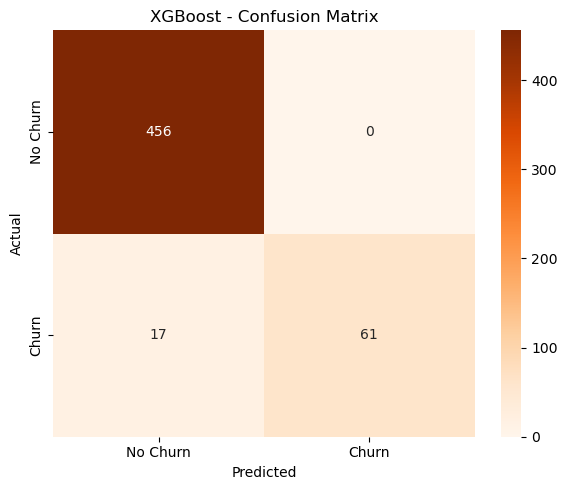

In [5]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred_xgb),
    annot=True, fmt="d", cmap="Oranges",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.title("XGBoost - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

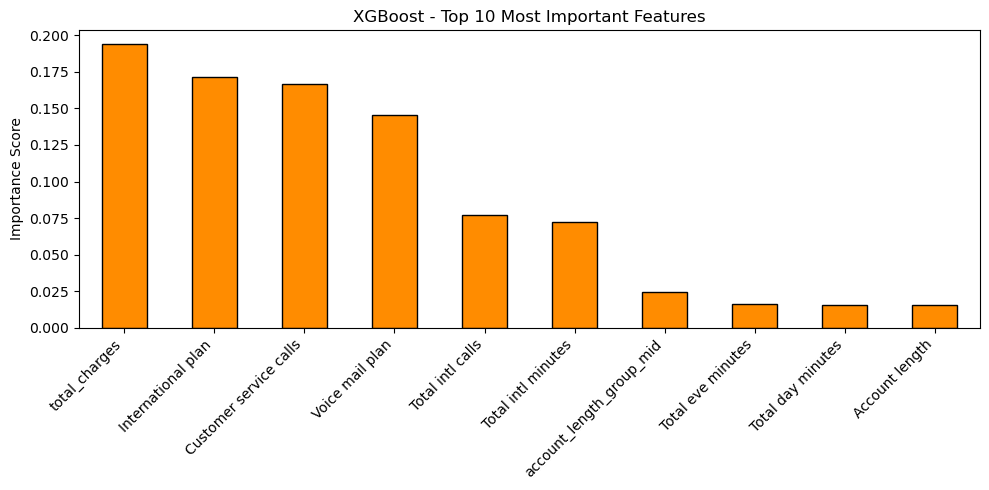


Top 10 Features:
total_charges               0.1937
International plan          0.1712
Customer service calls      0.1670
Voice mail plan             0.1456
Total intl calls            0.0772
Total intl minutes          0.0725
account_length_group_mid    0.0245
Total eve minutes           0.0164
Total day minutes           0.0156
Account length              0.0155
dtype: float32


In [6]:
feat_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feat_importance.head(10).plot(kind="bar", figsize=(10, 5), color="darkorange", edgecolor="black")
plt.title("XGBoost - Top 10 Most Important Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
print(feat_importance.head(10).round(4))

In [7]:
# Cross Validation


from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1        = cross_val_score(xgb_model, X, y, cv=skf, scoring="f1")
cv_accuracy  = cross_val_score(xgb_model, X, y, cv=skf, scoring="accuracy")
cv_precision = cross_val_score(xgb_model, X, y, cv=skf, scoring="precision")
cv_recall    = cross_val_score(xgb_model, X, y, cv=skf, scoring="recall")
cv_roc_auc   = cross_val_score(xgb_model, X, y, cv=skf, scoring="roc_auc")






In [8]:
# Results 

print("5-Fold Cross-Validation Results (Churn Class)\n")
print(f"F1 Score:   {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}   per fold: {np.round(cv_f1, 4)}")
print(f"Accuracy:   {cv_accuracy.mean():.4f} +/- {cv_accuracy.std():.4f}   per fold: {np.round(cv_accuracy, 4)}")
print(f"Precision:  {cv_precision.mean():.4f} +/- {cv_precision.std():.4f}   per fold: {np.round(cv_precision, 4)}")
print(f"Recall:     {cv_recall.mean():.4f} +/- {cv_recall.std():.4f}   per fold: {np.round(cv_recall, 4)}")
print(f"ROC-AUC:    {cv_roc_auc.mean():.4f} +/- {cv_roc_auc.std():.4f}   per fold: {np.round(cv_roc_auc, 4)}")

print(f"\nSingle split F1 from earlier: 0.9103")
print(f"CV mean F1:                   {cv_f1.mean():.4f}")

5-Fold Cross-Validation Results (Churn Class)

F1 Score:   0.9136 +/- 0.0116   per fold: [0.8951 0.9155 0.9306 0.9091 0.9178]
Accuracy:   0.9767 +/- 0.0030   per fold: [0.9719 0.9775 0.9812 0.9756 0.9775]
Precision:  0.9940 +/- 0.0074   per fold: [0.9846 1.     1.     1.     0.9853]
Recall:     0.8454 +/- 0.0177   per fold: [0.8205 0.8442 0.8701 0.8333 0.859 ]
ROC-AUC:    0.9222 +/- 0.0052   per fold: [0.925  0.9137 0.9259 0.9188 0.9277]

Single split F1 from earlier: 0.9103
CV mean F1:                   0.9136


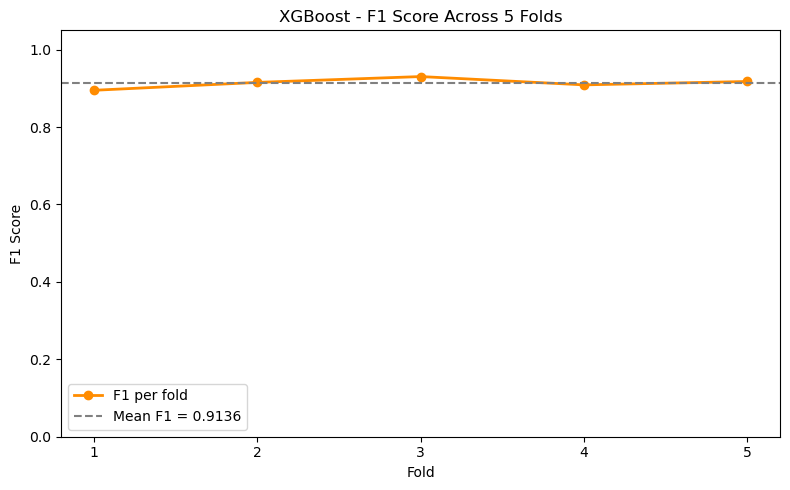

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), cv_f1, marker="o", color="darkorange", linewidth=2, label="F1 per fold")
plt.axhline(cv_f1.mean(), linestyle="--", color="gray", label=f"Mean F1 = {cv_f1.mean():.4f}")
plt.title("XGBoost - F1 Score Across 5 Folds")
plt.xlabel("Fold")
plt.ylabel("F1 Score")
plt.xticks(range(1, 6))
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

By using 5-fold stratified cross-validation we get a more honest estimate of how the model will perform on unseen customers. If the mean F1 score across all five folds remains close to our original result of 0.91 with a low standard deviation, it confirms that the model generalises consistently and that our single-split result was not a fluke. As evident from the graph above our model is validated as a strong predictor for customer churn patterns. 